In [2]:
suppressPackageStartupMessages({
    library(dplyr)
    library(magrittr)
    library(readr)
    library(ggplot2)
    library(tictoc)
    library(ggrastr)
    library(RColorBrewer)
    library(cowplot)
    library(reshape2)
    library(data.table)
    library(sccore)
    library(NMF)
    library(ggplot2)
    library(CRF)
    library(ggrepel)
    library(arrow)
    library(parallel)
    library(igraph)
    library(gtools)
    library(RColorBrewer)
    library(Matrix)
    library(readr)
    library(Seurat)
    library(sparseMatrixStats)
    library(cowplot)
    library(devtools)
    library(RANN)
    library(grid)
})

suppressMessages({
    devtools::load_all('./cellAdmix')
    devtools::load_all('./cellAdmix-Notebooks')
})

In [3]:
# load the molecule-level NSCLC spatial data
# these functions are from cellAdmix-Notebooks/data_loading.R
cell_meta <- prepare_nsclc_metadata(reps='one')
df <- prepare_nsclc_transcript_data(cell_meta,reps='one')


In [4]:
# also load a corresponding scRNA-seq dataset
so_rna <- prepare_nsclc_scrna()

In [5]:
# load precomputed already cleaned df, such as those produced in NSCLC_tutorial_fulldata.ipynb
df_cln <- readRDS('./nsclc_dat_cln.rds')
crf_res <- readRDS('./crf_joint_k15.rds')
fp_checks <- readRDS('./nsclc_fpchecks.rds')

In [6]:
# compute cell adjacency matrix needed for admixture probability scores calculation
sc_ctypes <- unique(so_rna$celltype)
df_ct_match <- df[df$celltype %in% sc_ctypes,]
df_cln <- df_cln[df_cln$celltype %in% sc_ctypes,]
cell_adj_df <- estimate_cell_adjacency(df_ct_match, random.shift=1e-2, n.cores=30)
celltype_adj_mat <- estimate_celltype_adjacency(cell_adj_df)

In [7]:
# estimate gene-gene correlations across datasets
so_spatial <- get_counts_meta_seurat(df)
so_spatial <- NormalizeData(so_spatial)
common_genes <- intersect(rownames(so_rna), rownames(so_spatial))
length(common_genes)
so_spatial %<>% subset(features=common_genes)
so_rna %<>% subset(features=common_genes)
cor_cors <- estimate_correlation_preservation(so_spatial[['RNA']]$data, so_rna[['RNA']]$data)

# exclude genes with low correlations
exclude_genes <- names(cor_cors)[cor_cors<.2]

[1] 958

In [8]:
# set other parameters for probability scores calculation
dbl_score_params <- list(
  signal_thres=0.4,
  exclude_genes=exclude_genes,
  p.c=.25,
  min.expr.frac=0.05,
  exclude.cell.types=NULL,
  max.prob.high=0.1
)

In [9]:
# first compute admixture probability scores for the original spatial data and scRNA-seq data
scores_orig <- get_dbl_scores(dbl_score_params,df_ct_match,so_rna,celltype_adj_mat,get_sc_scores=FALSE)
spatial_orig <- scores_orig[[1]]
sc_orig <- scores_orig[[2]]
spatial_orig$dataset <- 'spatial_orig'
sc_orig$dataset <- 'scRNAseq'

# now compute scores for the cleaned spatial data
scores_cln <- get_dbl_scores(dbl_score_params,df_cln,so_rna,celltype_adj_mat,get_sc_scores=FALSE)
scores_cln$dataset <- 'spatial_cln'

Warning message in FUN(X[[i]], ...):
“Genes with high expression in NK detected in contamination: 'HSPA1A'. Perhaps you should improve the annotation or mask these genes out (`exclude.genes`).”
Warning message in FUN(X[[i]], ...):
“Genes with high expression in malignant detected in contamination: 'VIM'. Perhaps you should improve the annotation or mask these genes out (`exclude.genes`).”
Warning message in FUN(X[[i]], ...):
“Genes with high expression in mast detected in contamination: 'CD74'. Perhaps you should improve the annotation or mask these genes out (`exclude.genes`).”
Warning message in spatial_orig$dataset <- "spatial_orig":
“Coercing LHS to a list”
Warning message in sc_orig$dataset <- "scRNAseq":
“Coercing LHS to a list”
Warning message in FUN(X[[i]], ...):
“Genes with high expression in NK detected in contamination: 'HSPA1A'. Perhaps you should improve the annotation or mask these genes out (`exclude.genes`).”
Warning message in FUN(X[[i]], ...):
“Genes with high express

In [10]:
# plot the resulting scores
plts <- plot_cell_score_ratios(
  scores_orig,scores_cln,fp_checks,df_ct_match,crf_res,
  upper.lim=1.5,min.mean.thresh=1e-3
)

Picking joint bandwidth of 0.0513



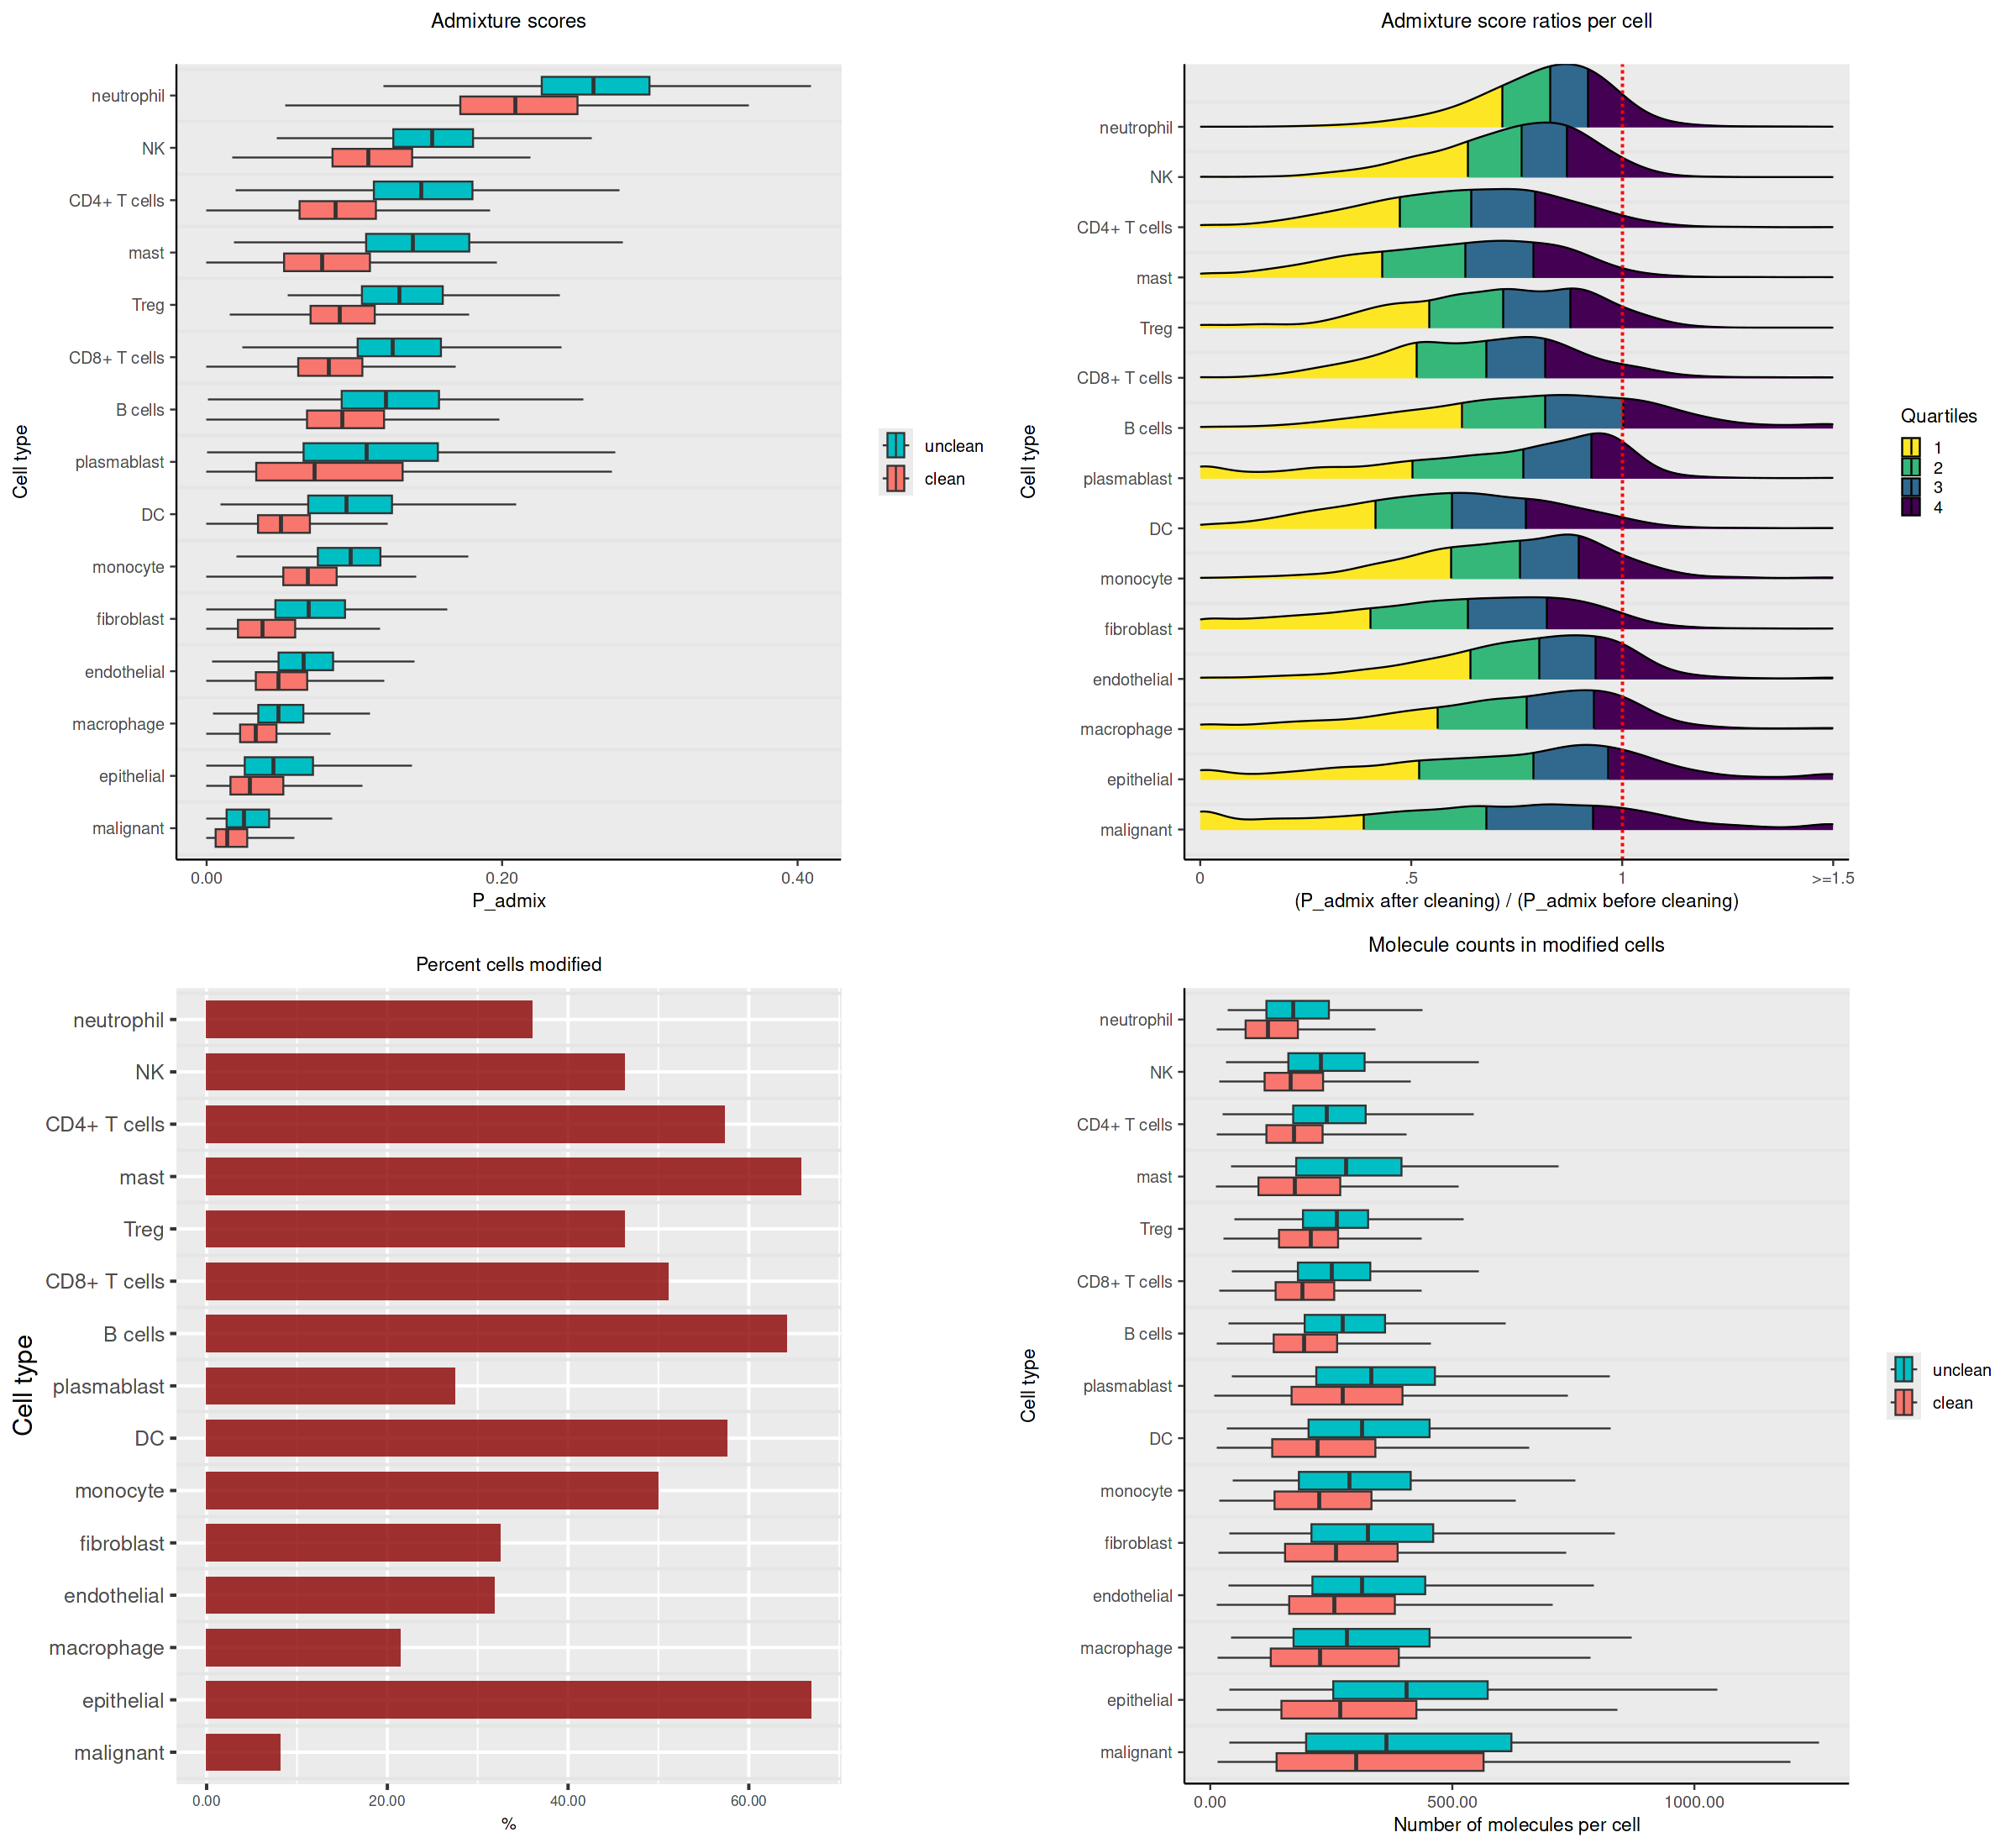

In [11]:
options(repr.plot.width = 12, repr.plot.height = 11, repr.plot.res = 200)
plot_grid(plotlist=plts,nrow=2,align='hv')